# Task 3: Multimodal ML — Housing Price Prediction Using Images + Tabular Data
**DevelopersHub Corporation — AI/ML Engineering Internship (Phase 2)**

**Objective:** Predict housing prices by combining structured (tabular) data — bedrooms, bathrooms, area, zip code — with house images (bedroom, bathroom, kitchen, frontal view), using a CNN for image feature extraction fused with a tabular branch.

**Dataset:** [Houses-dataset](https://github.com/emanhamed/Houses-dataset) (Ahmed & Moustafa) — 535 houses, each with 4 images + tabular attributes + sale price. Downloaded automatically via `git clone`, nothing manual.



In [1]:
# Cell 1: Install required libraries
!pip install -q tensorflow scikit-learn pandas matplotlib pillow

## Step 1: Download the Dataset (Images + Tabular Data)

In [2]:
# Cell 2: Clone the dataset repository
!git clone --depth 1 https://github.com/emanhamed/Houses-dataset.git

DATA_DIR = "Houses-dataset/Houses Dataset"
import os
print("Files found:", len(os.listdir(DATA_DIR)))

Cloning into 'Houses-dataset'...
remote: Enumerating objects: 2133, done.
remote: Counting objects: 100% (2133/2133), done.
remote: Compressing objects: 100% (2133/2133), done.
remote: Total 2133 (delta 0), reused 2129 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2133/2133), 176.26 MiB | 19.72 MiB/s, done.
Updating files: 100% (2144/2144), done.
Files found: 2141


## Step 2: Load Tabular Data

`HousesInfo.txt` has 4 numeric columns per house (space-separated, no header): `bedrooms`, `bathrooms`, `area`, `zipcode`, `price`.

In [3]:
# Cell 3: Load tabular attributes
import pandas as pd

cols = ["bedrooms", "bathrooms", "area", "zipcode", "price"]
df = pd.read_csv(f"{DATA_DIR}/HousesInfo.txt", sep=" ", header=None, names=cols)

print("Shape:", df.shape)
df.head()

Shape: (535, 5)


,bedrooms,bathrooms,area,zipcode,price
0,4,4.0,4053,85255,869500
1,4,3.0,3343,36372,865200
2,3,4.0,3923,85266,889000
3,5,5.0,4022,85262,910000
4,3,4.0,4116,85266,971226


## Step 3: Build Image Montages

Each house has 4 photos (bathroom, bedroom, frontal, kitchen). Following the standard approach for this dataset, we combine all 4 into a single 2x2 montage image per house — this montage becomes the CNN's single input image, so the model "sees" the whole house at once.

In [4]:
# Cell 4: Build a 2x2 montage image per house
import numpy as np
import cv2

IMG_SIZE = 64  # each individual photo resized to 64x64, montage becomes 128x128

def load_house_montage(house_id, data_dir=DATA_DIR, img_size=IMG_SIZE):
    room_types = ["bathroom", "bedroom", "frontal", "kitchen"]
    images = []
    for room in room_types:
        path = f"{data_dir}/{house_id}_{room}.jpg"
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        images.append(img)

    top_row = np.hstack([images[0], images[1]])
    bottom_row = np.hstack([images[2], images[3]])
    montage = np.vstack([top_row, bottom_row])
    return montage

# Build montages for every house (house IDs run from 1 to len(df))
house_ids = list(range(1, len(df) + 1))
images = np.array([load_house_montage(hid) for hid in house_ids])

print("Images array shape:", images.shape)  # (num_houses, 128, 128, 3)

Images array shape: (535, 128, 128, 3)


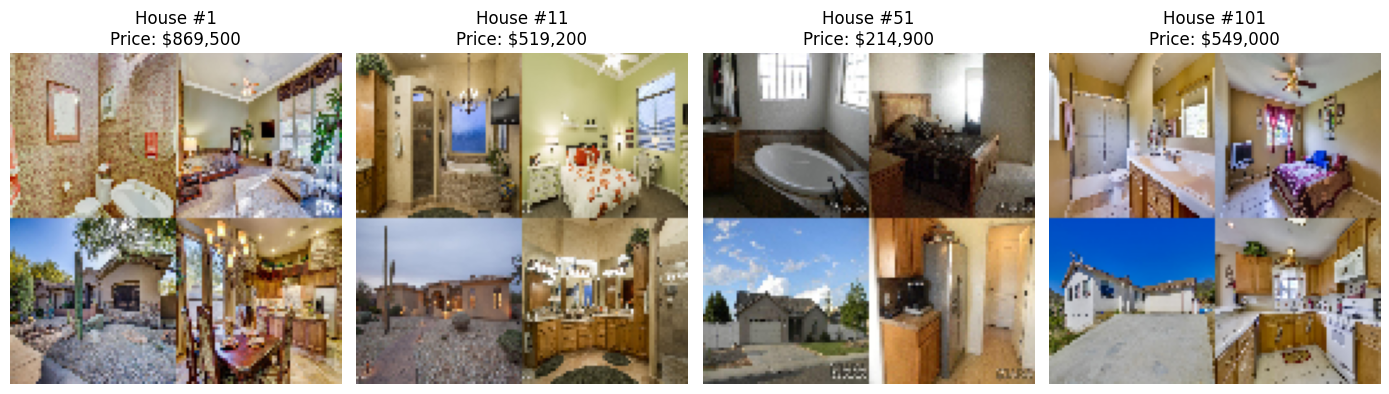

In [5]:
# Cell 5: Preview a few montages
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, idx in zip(axes, [0, 10, 50, 100]):
    ax.imshow(images[idx])
    ax.set_title(f"House #{house_ids[idx]}\nPrice: ${df.iloc[idx]['price']:,.0f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4: Preprocess Tabular Data

- Continuous features (`bedrooms`, `bathrooms`, `area`) → scaled to [0, 1] with `MinMaxScaler`.
- `zipcode` → one-hot encoded (categorical location signal).
- Target (`price`) → also scaled to [0, 1] for stable training; predictions are converted back to real dollar values before computing MAE/RMSE.

In [6]:
# Cell 6: Train/test split (splitting indices so images and tabular rows stay aligned)
from sklearn.model_selection import train_test_split

indices = np.arange(len(df))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_df, test_df = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)
train_images, test_images = images[train_idx], images[test_idx]

print("Train:", train_df.shape, train_images.shape)
print("Test:", test_df.shape, test_images.shape)

Train: (428, 5) (428, 128, 128, 3)
Test: (107, 5) (107, 128, 128, 3)


In [7]:
# Cell 7: Preprocess tabular features
from sklearn.preprocessing import MinMaxScaler

continuous_cols = ["bedrooms", "bathrooms", "area"]

cont_scaler = MinMaxScaler()
train_continuous = cont_scaler.fit_transform(train_df[continuous_cols])
test_continuous = cont_scaler.transform(test_df[continuous_cols])

# One-hot encode zipcode, aligning columns between train and test
train_zip = pd.get_dummies(train_df["zipcode"].astype(str))
test_zip = pd.get_dummies(test_df["zipcode"].astype(str))
train_zip, test_zip = train_zip.align(test_zip, join="left", axis=1, fill_value=0)

train_tabular = np.hstack([train_continuous, train_zip.values]).astype("float32")
test_tabular = np.hstack([test_continuous, test_zip.values]).astype("float32")

print("Tabular feature shape (train/test):", train_tabular.shape, test_tabular.shape)

Tabular feature shape (train/test): (428, 49) (107, 49)


In [8]:
# Cell 8: Scale the target (price) to [0, 1] for training stability
price_scaler = MinMaxScaler()
train_price_scaled = price_scaler.fit_transform(train_df[["price"]]).flatten()
test_price_scaled = price_scaler.transform(test_df[["price"]]).flatten()

# Normalize images to [0, 1]
train_images_norm = train_images.astype("float32") / 255.0
test_images_norm = test_images.astype("float32") / 255.0

## Step 5: Build the Multimodal Model

Two branches feeding into a shared regression head:
- **CNN branch:** extracts visual features from the house montage image.
- **MLP branch:** processes the tabular features (bedrooms, bathrooms, area, zipcode).
- The two feature vectors are **concatenated** and passed through a final dense regression head that outputs a single scaled price.

In [9]:
# Cell 9: Define the model
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_cnn_branch(input_shape=(IMG_SIZE*2, IMG_SIZE*2, 3)):
    inputs = layers.Input(shape=input_shape, name="image_input")
    x = layers.Conv2D(16, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    return inputs, x

def build_mlp_branch(input_dim, name="tabular_input"):
    inputs = layers.Input(shape=(input_dim,), name=name)
    x = layers.Dense(32, activation="relu")(inputs)
    x = layers.Dense(16, activation="relu")(x)
    return inputs, x

image_input, image_features = build_cnn_branch()
tabular_input, tabular_features = build_mlp_branch(train_tabular.shape[1])

combined = layers.concatenate([image_features, tabular_features])
x = layers.Dense(16, activation="relu")(combined)
output = layers.Dense(1, activation="sigmoid", name="price_output")(x)  # scaled price in [0,1]

model = Model(inputs=[image_input, tabular_input], outputs=output)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="mean_absolute_error")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16384)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 49)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │  1,048,640 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      1,600 │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │      1,296 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ price_output        │ (None, 1)         │         17 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,075,665 (4.10 MB)

 Trainable params: 1,075,665 (4.10 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

In [10]:
# Cell 10: Train
history = model.fit(
    x=[train_images_norm, train_tabular],
    y=train_price_scaled,
    validation_data=([test_images_norm, test_tabular], test_price_scaled),
    epochs=40,
    batch_size=8,
    verbose=1
)

Epoch 1/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 0.1013 - val_loss: 0.0908
Epoch 2/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0815 - val_loss: 0.0681
Epoch 3/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0708 - val_loss: 0.0516
Epoch 4/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0581 - val_loss: 0.0547
Epoch 5/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0503 - val_loss: 0.0348
Epoch 6/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0408 - val_loss: 0.0496
Epoch 7/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0366 - val_loss: 0.0407
Epoch 8/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0338 - val_loss: 0.0434
Epoch 9/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0333 - val_loss: 0.0301
Epoch 10/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0279 - val_loss: 0.0284
Epoch 11/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0255 - val_loss: 0.0273
Epoch 12/40
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0226 - val_

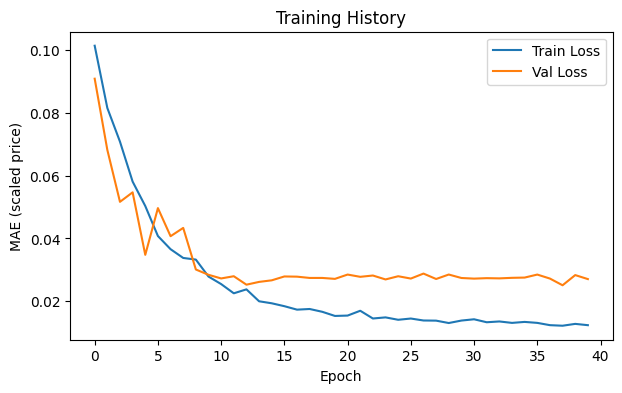

In [11]:
# Cell 11: Plot training curves
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled price)")
plt.title("Training History")
plt.legend()
plt.show()

## Step 7: Evaluate with MAE and RMSE (on real dollar scale)

In [12]:
# Cell 12: Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error

preds_scaled = model.predict([test_images_norm, test_tabular]).flatten()

# Convert predictions and true values back to real dollar prices
preds_dollars = price_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
true_dollars = test_df["price"].values

mae = mean_absolute_error(true_dollars, preds_dollars)
rmse = np.sqrt(mean_squared_error(true_dollars, preds_dollars))
mean_price = true_dollars.mean()

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"Mean actual price: ${mean_price:,.2f}")
print(f"MAE as % of mean price: {(mae/mean_price)*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step
MAE:  $158,056.45
RMSE: $277,122.76
Mean actual price: $552,423.59
MAE as % of mean price: 28.61%


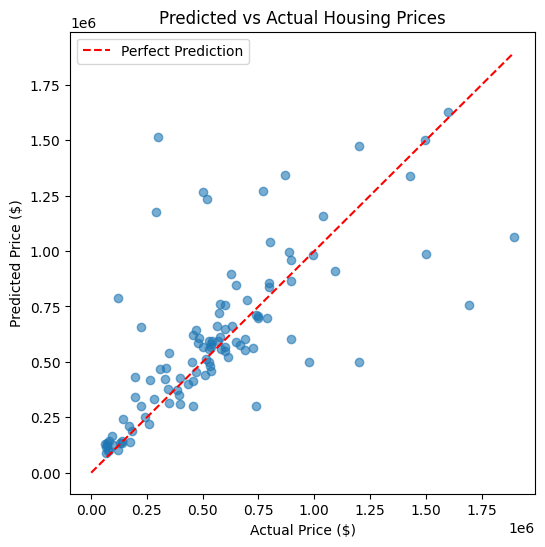

In [13]:
# Cell 13: Predicted vs Actual scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(true_dollars, preds_dollars, alpha=0.6)
max_val = max(true_dollars.max(), preds_dollars.max())
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect Prediction")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.title("Predicted vs Actual Housing Prices")
plt.legend()
plt.show()

## Step 8: Save the Trained Model

In [14]:
# Cell 14: Save model and scalers
model.save("multimodal_housing_price_model.keras")

import joblib
joblib.dump(cont_scaler, "continuous_scaler.joblib")
joblib.dump(price_scaler, "price_scaler.joblib")

print("Model and scalers saved.")

Model and scalers saved.


## Final Summary / Insights

- Combined **CNN-based image features** (from 2x2 montages of 4 house photos) with **tabular features** (bedrooms, bathrooms, area, one-hot encoded zipcode) using a **feature fusion (multi-input) architecture**.
- Trained the fused model to predict housing price, evaluated using **MAE** and **RMSE** on the real dollar scale (converted back from normalized predictions).
- Visualized training curves and a predicted-vs-actual scatter plot to assess model fit.
- This dataset is small (535 houses), so results are a proof-of-concept for the multimodal fusion technique rather than a production-accuracy model — performance would improve substantially with more data, data augmentation, and a deeper/pre-trained CNN backbone (e.g., transfer learning with MobileNet/ResNet on the image branch).

**Skills Gained:** Multimodal machine learning, Convolutional Neural Networks (CNNs), feature fusion (image + tabular), regression modeling and evaluation (MAE, RMSE).
